## Задача 1

Реализовать класс для работы с линейной регрессией

In [36]:
import pandas as pd
import numpy as np

class MyLinearRegression:
    """
    Parameters
    ----------
    regularization : {None, 'l1', 'l2', 'l1l2'}, default=None
        Какую регуляризацию добавить к модели. Если значение `None`, то без регуляризации.

    weight_calc : {'matrix', 'gd', 'sgd'}, default='matrix'
        Каким образом вычислять вектор весов: матрично ('matrix'), градиентным спуском ('gd') или стохастическим градиентным спуском ('sgd'). При этом, при 'l1' или 'l1l2' нельзя использовать параметр 'matrix'.

    Attributes
    ----------
    coefs_ : Вектор коэффициентов размера (p, 1), где p — количество признаков.
    intercept_ : Значение коэффициента, отвечающего за смещение
    """

    def __init__(self, regularization=None, weight_calc='matrix', lambda_1=None, lambda_2=None, batch_size=20, learning_rate=0.01, n_iter=1000):
        if regularization not in [None, 'l1', 'l2', 'l1l2']:
            raise TypeError(f"Параметр regularization не может принимать значение '{regularization}'")
        if weight_calc not in ['matrix', 'gd', 'sgd']:
            raise TypeError(f"Параметр weight_calc не может принимать значение '{weight_calc}'")
        if regularization in ['l1', 'l1l2'] and lambda_1 is None:
            raise TypeError(f"Значение коэффициента регулризации l1 не задано")
        if regularization in ['l2', 'l1l2'] and lambda_2 is None:
            raise TypeError(f"Значение коэффициента регулризации l2 не задано")

        self.regularization = regularization
        self.weight_calc = weight_calc
        self.lambda_1 = lambda_1 if lambda_1 is not None else 0
        self.lambda_2 = lambda_2 if lambda_2 is not None else 0
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.n_iter = n_iter

        self.coefs_ = None
        self.intercept_ = None


    def fit(self, X: pd.DataFrame, y: pd.DataFrame):
        X_mat = X.values
        y_vec = y.values.flatten()

        n_samples, n_features = X_mat.shape

        X_b = np.c_[np.ones((n_samples, 1)), X_mat]
        weights = np.zeros(n_features + 1)

        if self.weight_calc == 'matrix':
            if self.regularization == 'l1' or self.regularization == 'l1l2':
                raise ValueError("Матричный метод не поддерживает L1 регуляризацию")

            XT_X = X_b.T.dot(X_b)

            if self.regularization == 'l2':
                I = np.eye(n_features + 1)
                I[0, 0] = 0
                XT_X += self.lambda_2 * I

            inv_XT_X = np.linalg.inv(XT_X)
            weights = inv_XT_X.dot(X_b.T).dot(y_vec)
        else:
            for i in range(self.n_iter):
                if self.weight_calc == 'sgd':
                    indices = np.random.permutation(n_samples)
                    X_batch = X_b[indices[:self.batch_size]]
                    y_batch = y_vec[indices[:self.batch_size]]
                else:
                    X_batch = X_b
                    y_batch = y_vec

                y_pred = X_batch.dot(weights)

                error = y_pred - y_batch

                gradient = (2 / len(y_batch)) * X_batch.T.dot(error)

                w_no_bias = weights.copy()
                w_no_bias[0] = 0

                if self.regularization in ['l2', 'l1l2']:
                    gradient += 2 * self.lambda_2 * w_no_bias

                if self.regularization in ['l1', 'l1l2']:
                    gradient += self.lambda_1 * np.sign(w_no_bias)

                weights -= self.learning_rate * gradient

        self.intercept_ = weights[0]
        self.coefs_ = weights[1:].reshape(-1, 1)
    def predict(self, X: np.array, ss=True):
        if not isinstance(X, np.ndarray):
            X = np.array(X)

        return X.dot(self.coefs_).flatten() + self.intercept_

    def score(self, X: np.array, y: np.array):
        if not isinstance(X, np.ndarray): X = np.array(X)
        if not isinstance(y, np.ndarray): y = np.array(y).flatten()

        y_pred = self.predict(X)

        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)

        return 1 - (ss_res / ss_tot)

Используя датасет про автомобили (целевой признак — price), сравнить (качество, скорость обучения и предсказания, важность признаков) модели `MyLinearRegression` с различными гиперпараметрами, сделать выводы. На этом же датасете сравнить модель `MyLinearRegression` с библиотечной реализацией из `sklearn`, составить таблицу(ы) (графики) результатов сравнения (качество, скорость обучения и предсказания, важность признаков).

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
import time

In [38]:
df = pd.read_csv('Used_fiat_500_in_Italy_dataset.csv')

In [39]:
df_dummy = pd.get_dummies(df)

In [40]:
X = df_dummy.drop(columns=['price'])
y = df_dummy['price']

In [41]:
X = X.fillna(X.mean())

In [42]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [44]:
def test_model(model, name, X_tr, y_tr, X_te, y_te):
    results = {}
    results['Model'] = name

    start_time = time.time()
    model.fit(X_tr, y_tr)
    results['Train Time (s)'] = time.time() - start_time

    start_time = time.time()

    preds = model.predict(X_te)
    results['Predict Time (s)'] = time.time() - start_time

    results['R2 Score'] = r2_score(y_te, preds)
    results['MSE'] = mean_squared_error(y_te, preds)

    return results

In [45]:
experiments = []

# Наша модель - матричная
my_lr_matrix = MyLinearRegression(weight_calc='matrix')
experiments.append(test_model(my_lr_matrix, 'MyLR (Matrix)', X_train, y_train, X_test, y_test))

# Наша модель - GD + L2
my_lr_gd = MyLinearRegression(weight_calc='gd', regularization='l2', lambda_2=0.5, learning_rate=0.1, n_iter=2000)
experiments.append(test_model(my_lr_gd, 'MyLR (GD + L2)', X_train, y_train, X_test, y_test))

# Наша модель - SGD + L1
my_lr_sgd = MyLinearRegression(weight_calc='sgd', regularization='l1', lambda_1=10, learning_rate=0.01, n_iter=3000, batch_size=10)
experiments.append(test_model(my_lr_sgd, 'MyLR (SGD + L1)', X_train, y_train, X_test, y_test))

# Sklearn базовая
sklearn_lr = LinearRegression()
experiments.append(test_model(sklearn_lr, 'Sklearn LR', X_train, y_train, X_test, y_test))

# Sklearn Ridge (L2)
sklearn_ridge = Ridge(alpha=0.5)
experiments.append(test_model(sklearn_ridge, 'Sklearn Ridge', X_train, y_train, X_test, y_test))

In [46]:
results_df = pd.DataFrame(experiments)

,Model,Train Time (s),Predict Time (s),R2 Score,MSE
0,MyLR (Matrix),0.0011,0.0002,0.7609,1.220519e+06
1,MyLR (GD + L2),0.0612,0.0002,0.8246,8.951639e+05
2,MyLR (SGD + L1),0.1658,0.0001,0.8851,5.863338e+05
3,Sklearn LR,0.0031,0.0017,0.8945,5.383617e+05
4,Sklearn Ridge,0.0026,0.0014,0.8945,5.386934e+05


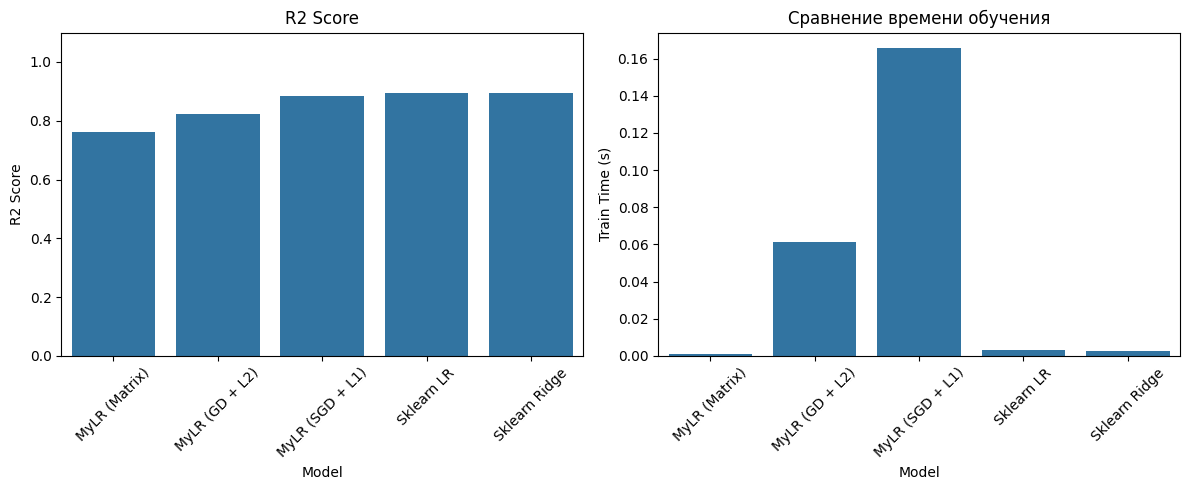

In [47]:
display(results_df.round(4))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='R2 Score', data=results_df)
plt.title('R2 Score')
plt.xticks(rotation=45)
plt.ylim(0, 1.1)

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Train Time (s)', data=results_df)
plt.title('Сравнение времени обучения')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

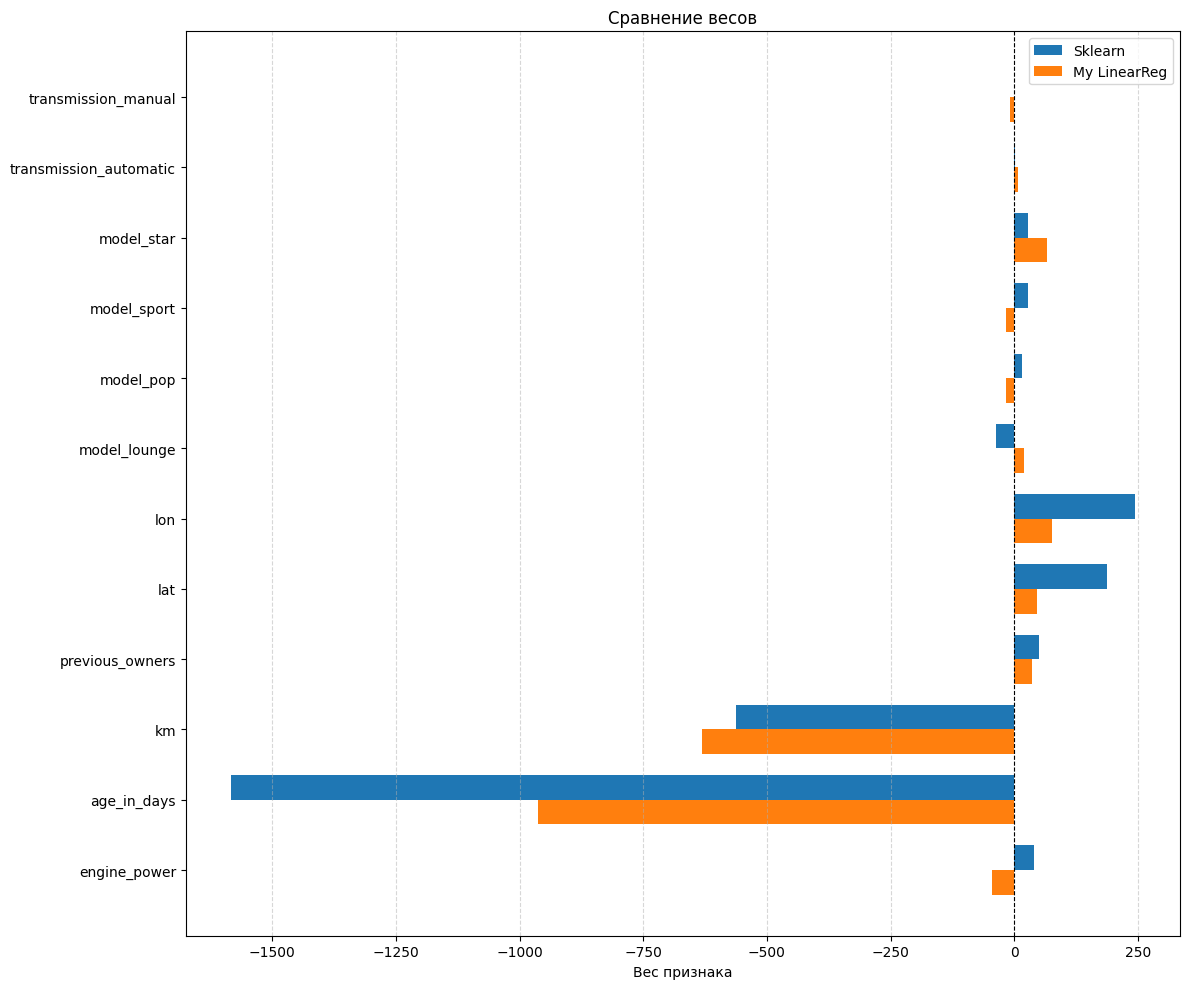

In [48]:
plt.figure(figsize=(12, 10))

my_weights = my_lr_gd.coefs_.flatten()

sklearn_weights = sklearn_lr.coef_

feature_names = X.columns
n_features = len(feature_names)

indices = np.arange(n_features)
width = 0.35

plt.barh(indices + width/2, sklearn_weights, width, label='Sklearn')

plt.barh(indices - width/2, my_weights, width, label='My LinearReg')

plt.yticks(indices, feature_names)
plt.xlabel('Вес признака')
plt.title('Сравнение весов')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Задача 2

[Соревнование на Kaggle](https://kaggle.com/competitions/yadro-regression-2025)